# MULTIPLE LINEAR REGRESSION MODEL FOR PREDICTING ENERGY CONSUMPTION

### There are 9 predictors variables in the model of which 5 are countinuous and 4 categorical.

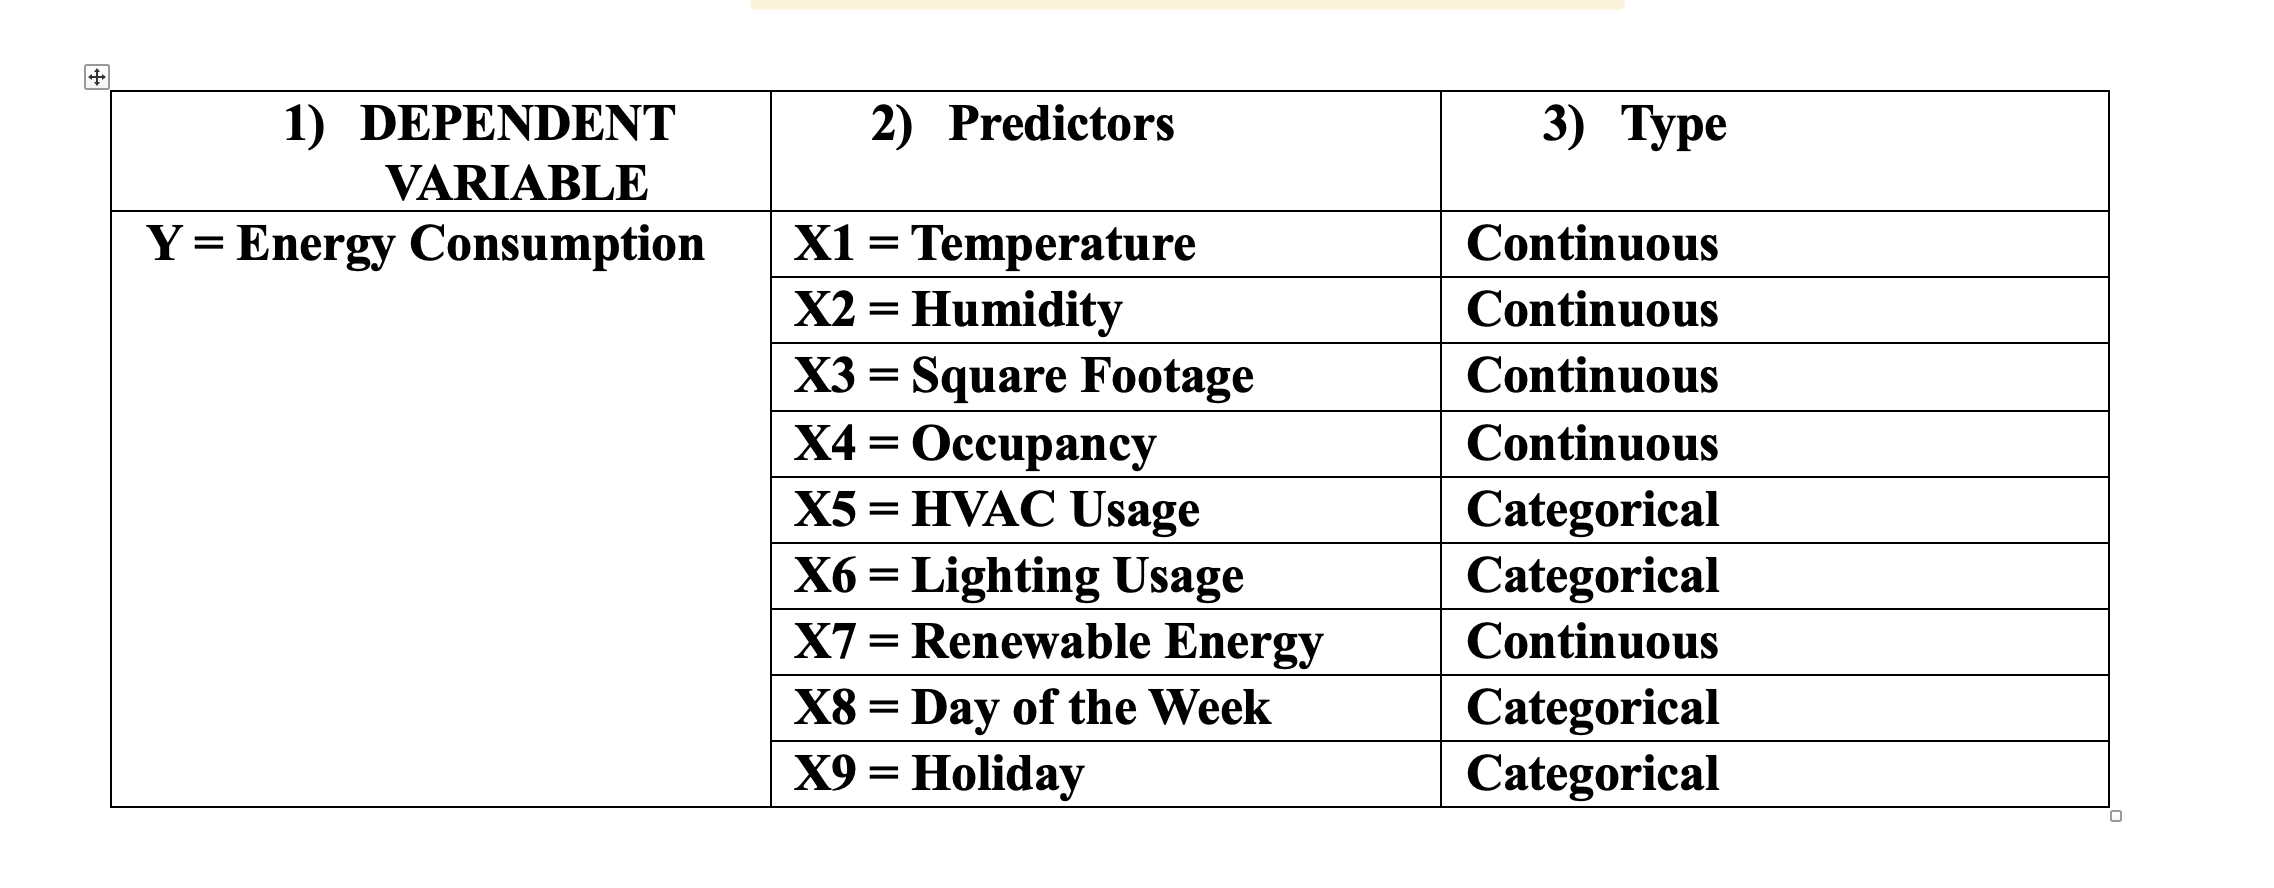

### MAIN QUESTIONS
- How do temperature and humidity affect energy consumption?
- How can our findings impact different areas such as businesses, utility companies, or consumers?
- Which variables / predictors are the most significant to the model or have the greatest influence on Y?


LIBRARIES WE UTILIZED

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

IMPORTING DATA FROM CSV

In [ ]:
data = pd.read_csv("https://raw.githubusercontent.com/Pperez4/630-project/refs/heads/main/Energy_data_file.csv")

TAKING A LOOK AT THE FIRST FEW RECORDS IN THE DATA

In [ ]:
data.head(1)

,Timestamp,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,DayOfWeek,Holiday,EnergyConsumption
0,2022-01-01 00:00:00,25.139433,43.431581,1565.693999,5,On,Off,2.774699,Monday,No,75.364373


Utilizing .info() we got an insight into the data types and a positive aspect of this dataset is that we don't have null values.

However, some of the variables need to be properly encoded such as --->
* HVACUsage
  * 1 -> yes
  * 0 -> no
* LightingUsage
  * 1 -> yes
  * 0 -> no
* DayOfWeek
  * k - 1 dummy variables
* Holiday
  * 1 -> yes
  * 0 -> no

A variable that will not be utilized as a predictor of the model is 'Timestamp'.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          1000 non-null   object 
 1   Temperature        1000 non-null   float64
 2   Humidity           1000 non-null   float64
 3   SquareFootage      1000 non-null   float64
 4   Occupancy          1000 non-null   int64  
 5   HVACUsage          1000 non-null   object 
 6   LightingUsage      1000 non-null   object 
 7   RenewableEnergy    1000 non-null   float64
 8   DayOfWeek          1000 non-null   object 
 9   Holiday            1000 non-null   object 
 10  EnergyConsumption  1000 non-null   float64
dtypes: float64(5), int64(1), object(5)
memory usage: 86.1+ KB


In [ ]:
# dropping the 'Timestamp'
data.drop(columns='Timestamp', inplace=True)

In [ ]:
# encoding HVACUsage --> On = 1, Off = 0
data['HVACUsage'] = data['HVACUsage'].map({'On': 1, 'Off': 0})
# encoding LightingUsage --> On = 1, Off = 0
data['LightingUsage'] = data['LightingUsage'].map({'On': 1, 'Off': 0})
# encoding Holiday --> Yes = 1, No = 0
data['Holiday'] = data['Holiday'].map({'Yes': 1, 'No': 0})
# getting k-1 dummy variables for 'DayOfWeek'
data = pd.get_dummies(data, columns=['DayOfWeek'], drop_first=True, dtype=int)

In [ ]:
data.head(1)

,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,Holiday,EnergyConsumption,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,25.139433,43.431581,1565.693999,5,1,0,2.774699,0,75.364373,1,0,0,0,0,0


In this case for the categorical variable 'DayOfWeek'the dropped day was friday which becomes the reference variable.

In [ ]:
# Variables to be used as predictors
X_predictors = data.drop(columns="EnergyConsumption")
X_predictors.head(1)

,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,Holiday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday
0,25.139433,43.431581,1565.693999,5,1,0,2.774699,0,1,0,0,0,0,0


In [ ]:
# Variable used as dependent variavle
Y_variable = data['EnergyConsumption']
Y_variable.head(1)

,EnergyConsumption
0,75.364373


### DATA VISUALIZATION

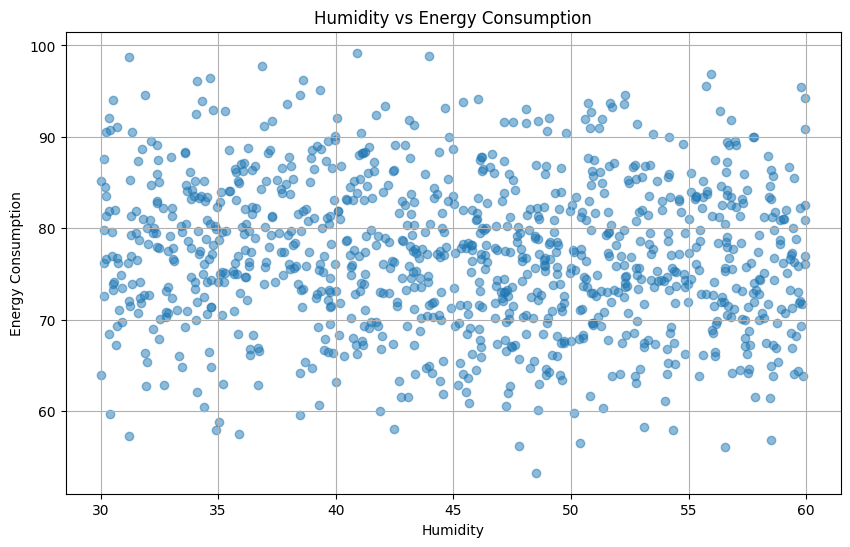

In [ ]:
# Making the scatter to the the relationship between Energy Consumption and Temperature
plt.figure(figsize=(10, 6))
plt.scatter(data['Humidity'], data['EnergyConsumption'], alpha=0.5)
plt.title('Humidity vs Energy Consumption')
plt.xlabel('Humidity')
plt.ylabel('Energy Consumption')
plt.grid(True)
plt.show()

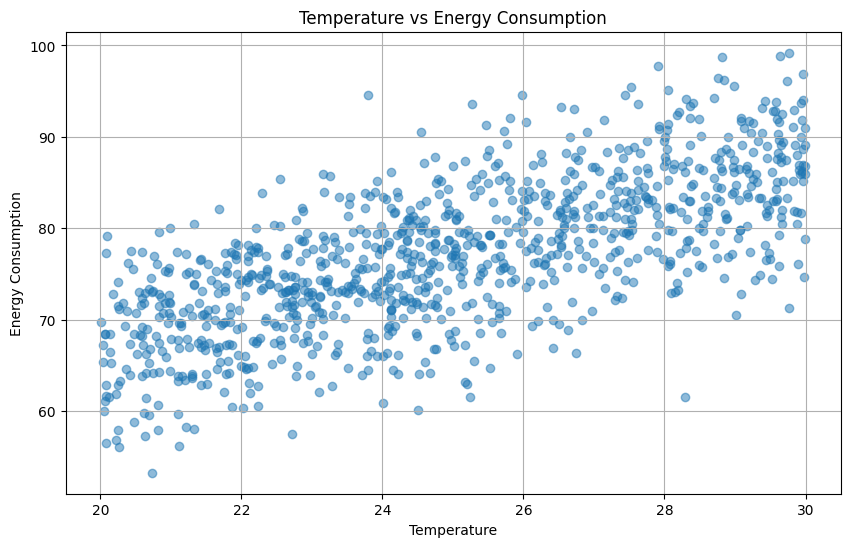

In [ ]:

# Making the scatter to the the relationship between Energy Consumption and Temperature
plt.figure(figsize=(10, 6))
plt.scatter(data['Temperature'], data['EnergyConsumption'], alpha=0.5)
plt.title('Temperature vs Energy Consumption')
plt.xlabel('Temperature')
plt.ylabel('Energy Consumption')
plt.grid(True)
plt.show()

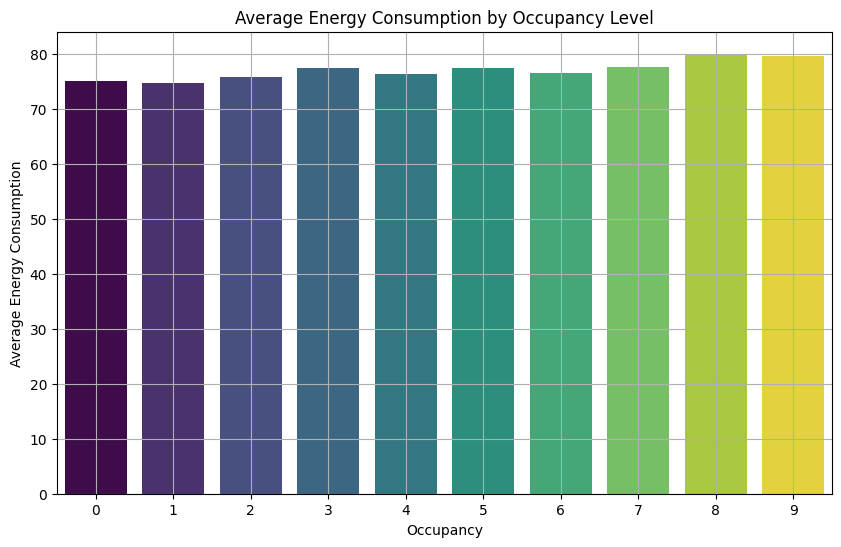

In [ ]:
# Group by occupancy and average energy consumption
occupancy_avg = data.groupby('Occupancy')['EnergyConsumption'].mean().reset_index()

# Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=occupancy_avg, x='Occupancy', y='EnergyConsumption', hue='Occupancy', palette='viridis', legend=False)
plt.title('Average Energy Consumption by Occupancy Level')
plt.xlabel('Occupancy')
plt.ylabel('Average Energy Consumption')
plt.grid(True)
plt.show()

### HEATMAP FOR CORRELATION



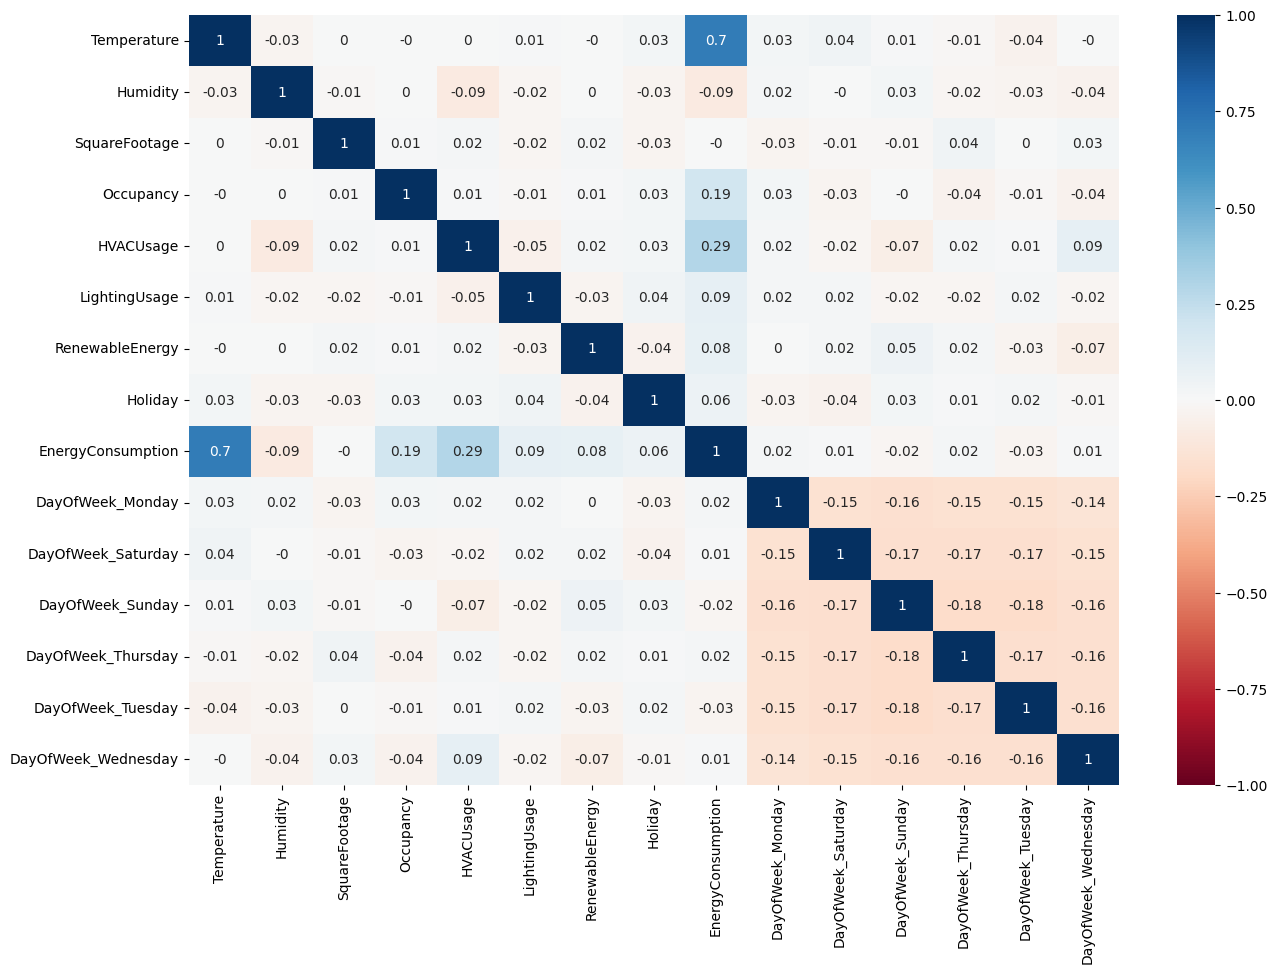

In [ ]:
corr_data = data.corr().round(2)
plt.figure(figsize=(15,10))
sns.heatmap(data=corr_data, vmin=-1, vmax=1, center=0, annot=True, cmap='RdBu')
plt.show()

# OLS REGRESSION OUTPUT
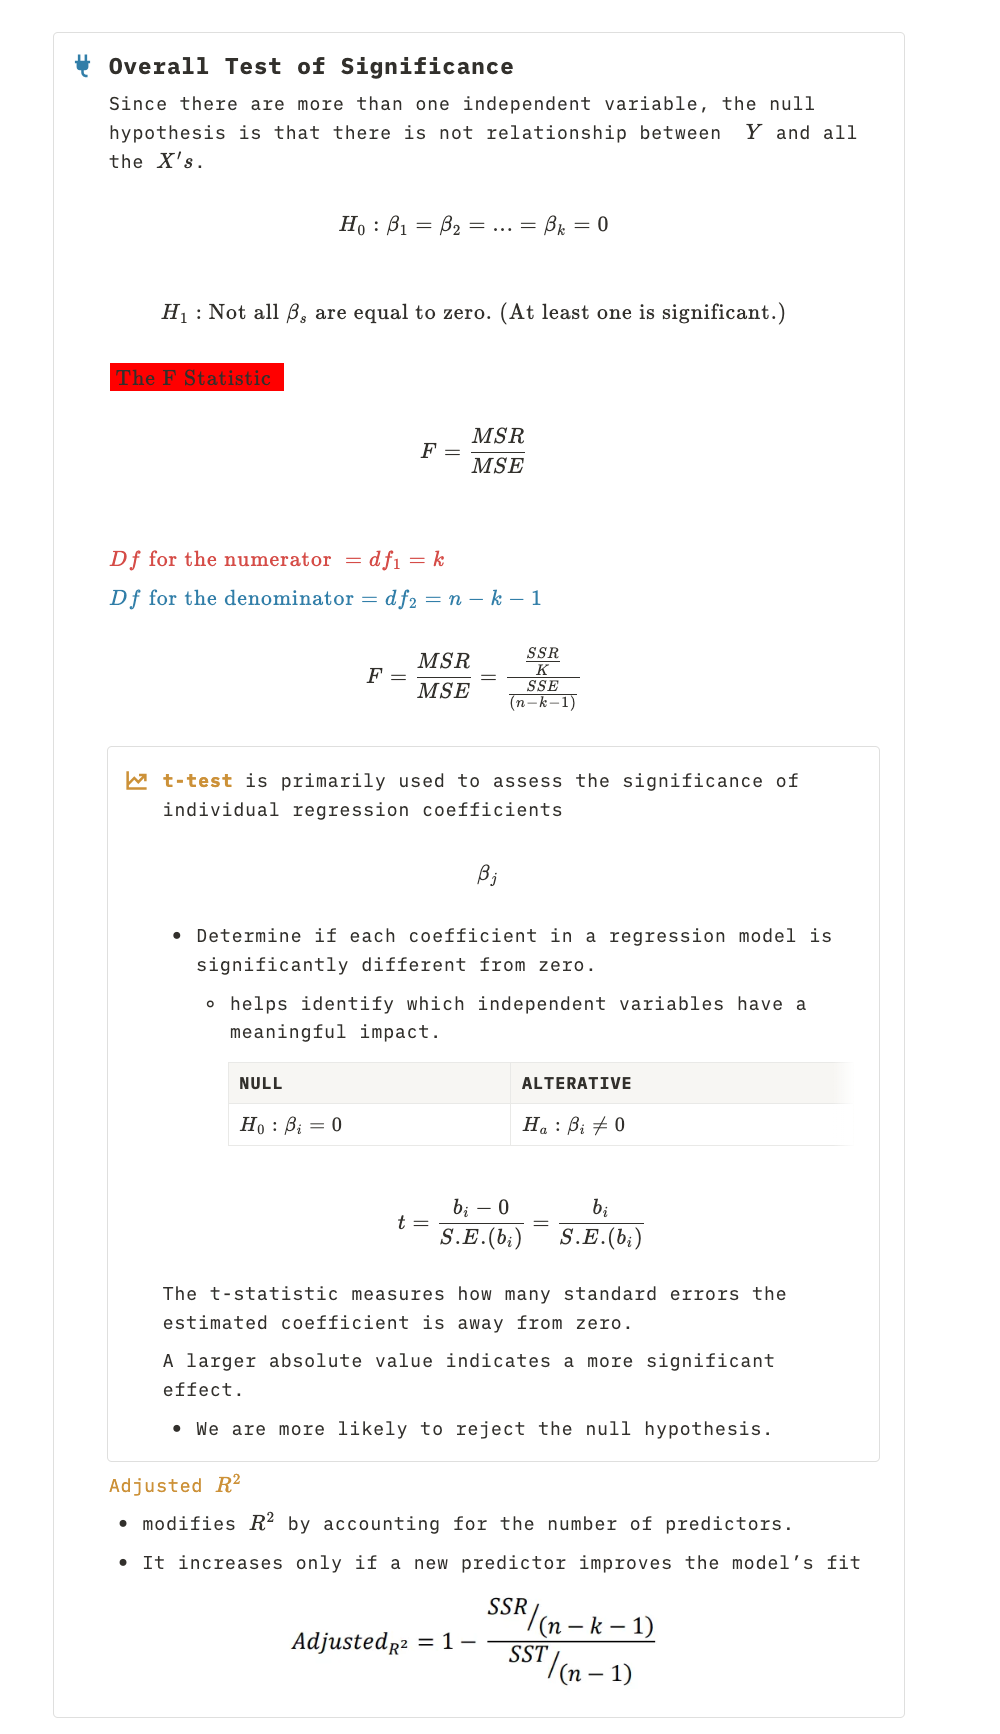

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
mlr = smf.ols(
    formula="EnergyConsumption ~ Temperature + Humidity + SquareFootage + Occupancy + HVACUsage + LightingUsage + RenewableEnergy + Holiday + DayOfWeek_Monday + DayOfWeek_Saturday + DayOfWeek_Sunday + DayOfWeek_Thursday + DayOfWeek_Tuesday + DayOfWeek_Wednesday",
    data=data
).fit()

In [ ]:
print(mlr.summary())

                            OLS Regression Results                            
Dep. Variable:      EnergyConsumption   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     115.1
Date:                Tue, 22 Apr 2025   Prob (F-statistic):          6.12e-196
Time:                        22:09:37   Log-Likelihood:                -3031.2
No. Observations:                1000   AIC:                             6092.
Df Residuals:                     985   BIC:                             6166.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              22.8302    

### SUMMARY OLD REGRESSION OUTPUT - taking an alpha of 0.05

* In summary the model as a whole is significant having a low p-value associated with it.

* When it comes to the individual coefficients t-test
  * SquareFootage - has a high p value an therefore is not significant to the model
  * Holiday - has a high p value an therefore is not significant to the model
  * DayOfWeek - - has a high p value an therefore is not significant to the model


  In contrast
  * Temperature
  * Humidity
  * Occupancy
  * HVACUsage
  * LightingUsage
  * RenewableEnergy
  
  Appear to be significant to the model, having p-values less than alpha associated with them.

# REGULAR MULTIPLE REGRESION MODEL TRAINING AND TESTING + CROSSVALIDATION

* 80% of data for training
* 20% for testing

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_predictors)

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled,Y_variable, test_size=0.2, random_state=42)
training_model = LinearRegression()
training_model.fit(X_train, Y_train)
y_predicted_tm = training_model.predict(X_test)
trained_model_R2 = r2_score(Y_test, y_predicted_tm)
print(f" Trained Model R squared:  {trained_model_R2}")
print(f" Trained Model MSE:", mean_squared_error(Y_test, y_predicted_tm))


 Trained Model R squared:  0.5947018607560564
 Trained Model MSE: 26.546977675822276


### CROSSVALIDATION


In [ ]:
regression = LinearRegression()
crossvalidate = KFold(n_splits=10,shuffle=True, random_state=1)
cv_score_r2 = cross_val_score(regression,X_train,Y_train, scoring='r2', cv=crossvalidate, n_jobs=1)
print("------------------------------------------------------------------------------------")
print("R2 folds ----> ")
for i in cv_score_r2:
  print(i)
print("------------------------------------------------------------------------------------")
print("Mean R2: " ,cv_score_r2.mean())
print("------------------------------------------------------------------------------------")

------------------------------------------------------------------------------------
R2 folds ----> 
0.5418823782891591
0.6587819666071243
0.6074297148093439
0.5496425585831808
0.6779178215816906
0.5895832803686378
0.6650997766255571
0.5221204557738434
0.630513286328047
0.5793225723735413
------------------------------------------------------------------------------------
Mean R2:  0.6022293811340125
------------------------------------------------------------------------------------


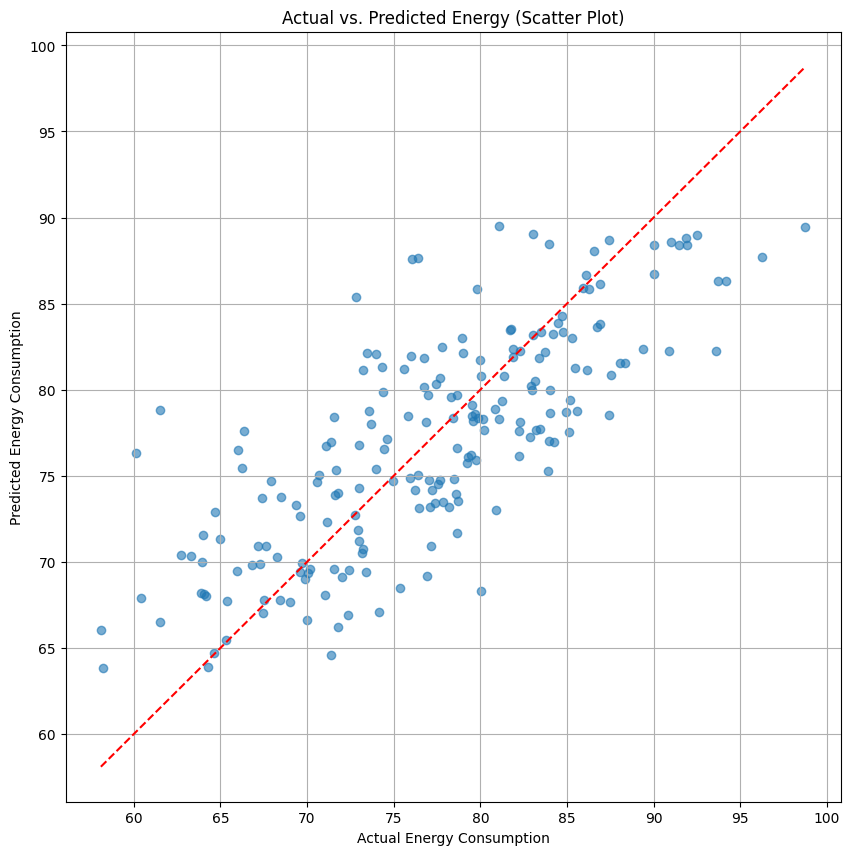

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(Y_test, y_predicted_tm, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'r--')  # Ideal line
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs. Predicted Energy (Scatter Plot)')
plt.grid(True)
plt.show()

# RESIDUALS PLOT

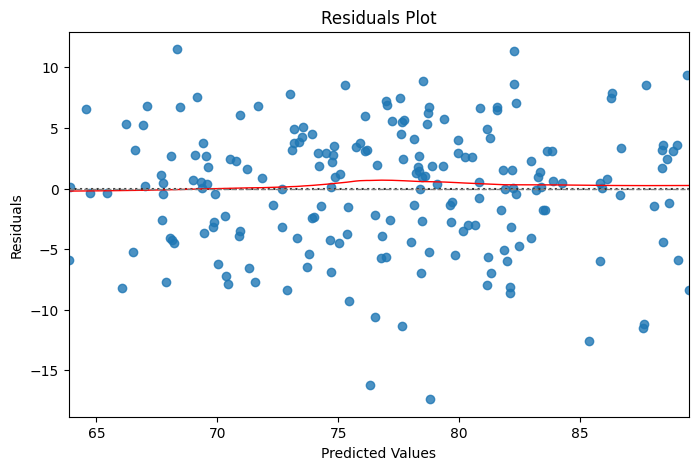

In [ ]:
plt.figure(figsize=(8, 5))
sns.residplot(x=y_predicted_tm, y=Y_test, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

# DEEP LEARNING MODEL

* Here we basically do the standard of splitting data into training
* 80 % training
* 20 % testing


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_predictors,Y_variable, test_size=0.2, random_state=42)

In [ ]:

scaler = StandardScaler().fit(X_train)
# Scale the train set
X_train= scaler.transform(X_train)
# Scale the test set
X_test= scaler.transform(X_test)

The neural network has 4 layers total
* Input layer
* Dense Layer 32 neurons
* Dense Layer 16 neurons
* Output layer -> 1 neuron to predict te continous variable of Energy Consumption

In [ ]:
from tensorflow.keras import models
from tensorflow.keras import layers

deep_model = models.Sequential()
deep_model.add(layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
deep_model.add(layers.Dense(16, activation='relu'))
deep_model.add(layers.Dense(1, activation='linear'))

deep_model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
deep_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = deep_model.fit(X_train, Y_train,epochs=10, batch_size=1, validation_data=(X_test, Y_test))

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 4441.4844 - mean_squared_error: 4441.4844 - val_loss: 57.4855 - val_mean_squared_error: 57.4855
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 50.0368 - mean_squared_error: 50.0368 - val_loss: 45.9106 - val_mean_squared_error: 45.9106
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 36.8551 - mean_squared_error: 36.8551 - val_loss: 42.7136 - val_mean_squared_error: 42.7136
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 35.2497 - mean_squared_error: 35.2497 - val_loss: 37.6127 - val_mean_squared_error: 37.6127
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 31.0245 - mean_squared_error: 31.0245 - val_loss: 36.5730 - val_mean_squared_error: 36.5730
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 31.2851 - mean_squared_error: 31.2851 - val_loss: 32.3689 - val_mean_squared_error: 32.3689
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 27.3126 - mean_squared

In [ ]:
y_predicted_dm = deep_model.predict(X_test).flatten()
deep_trained_model_R2 = r2_score(Y_test, y_predicted_dm)
print("----------------------------------------------------------------------")
print(f" Deep Trained Model R2:  {deep_trained_model_R2}")
print(f" Deep Trained Model MSE: {mean_squared_error(Y_test, y_predicted_dm)}")
print("----------------------------------------------------------------------")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
----------------------------------------------------------------------
 Deep Trained Model R2:  0.5246115839944706
 Deep Trained Model MSE: 31.137882080054197
----------------------------------------------------------------------


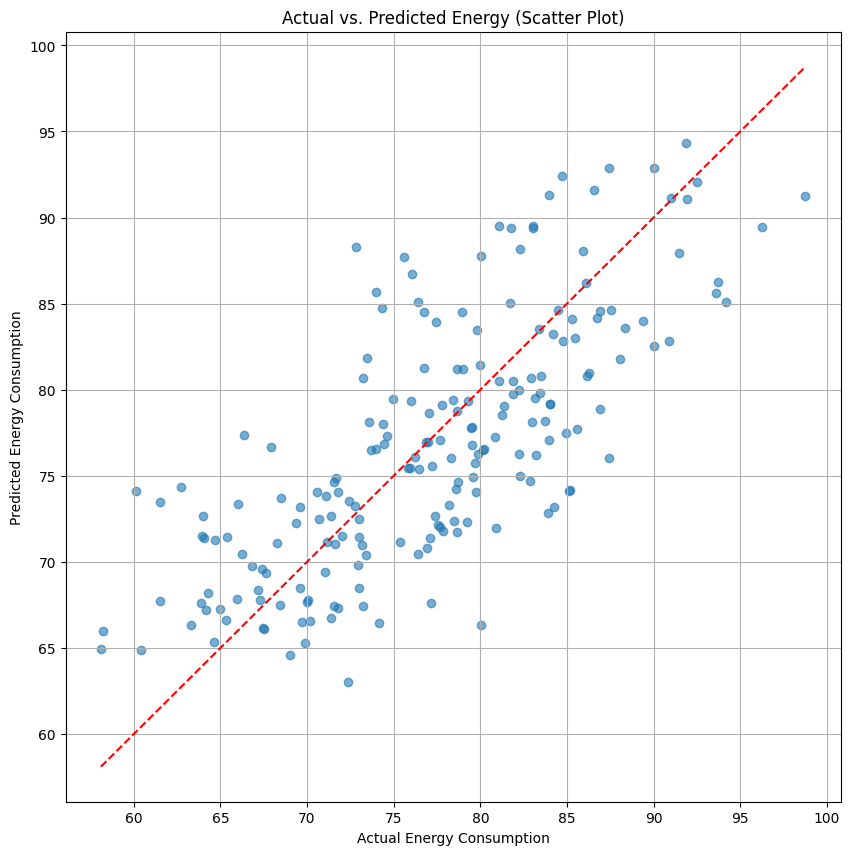

In [ ]:
plt.figure(figsize=(10, 10))
plt.scatter(Y_test, y_predicted_dm, alpha=0.6)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'r--')  # Ideal line
plt.xlabel('Actual Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Actual vs. Predicted Energy (Scatter Plot)')
plt.grid(True)
plt.show()

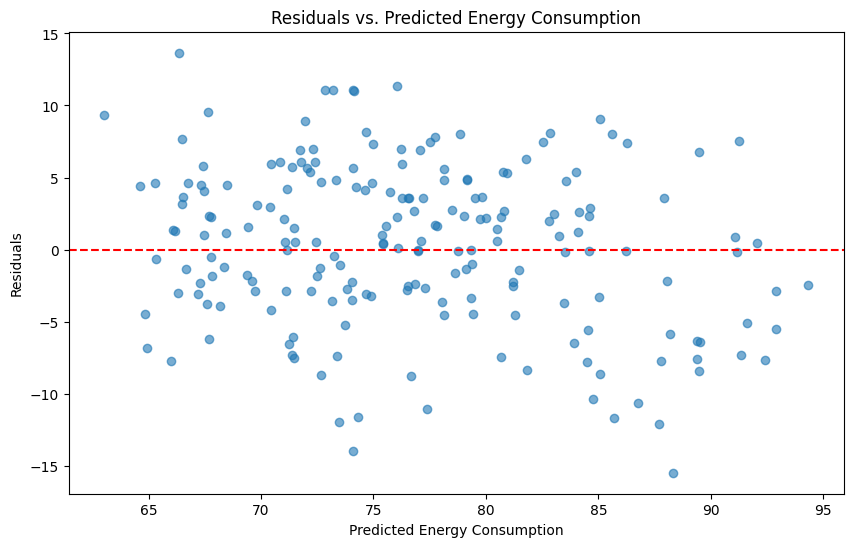

In [ ]:
residuals = Y_test - y_predicted_dm

plt.figure(figsize=(10, 6))
plt.scatter(y_predicted_dm, residuals, alpha=0.6)
plt.xlabel('Predicted Energy Consumption')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Energy Consumption')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

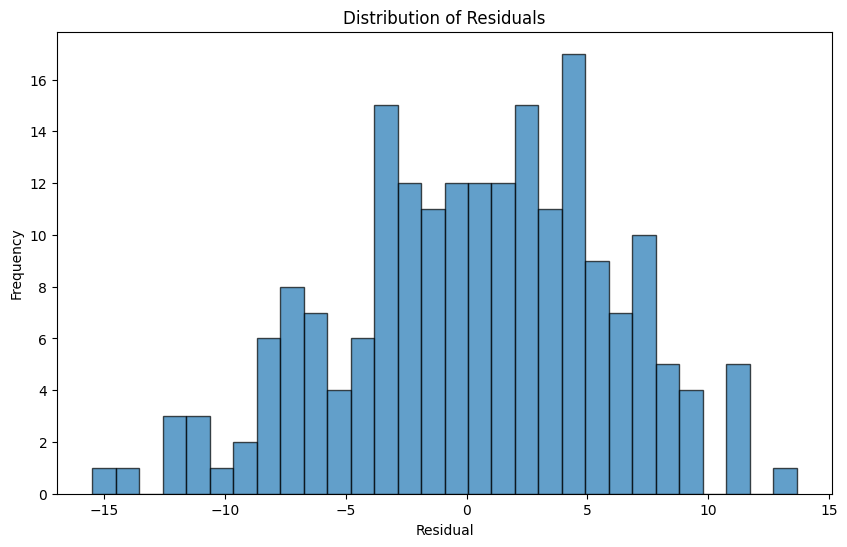

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()